##1. Package Installation and Environment Setup

In [1]:
import sys
import subprocess

def run_pip(*packages):
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", *packages
    ])

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchvision"],
    check=False
)

run_pip(
    "transformers==4.46.3",
    "sentencepiece>=0.2.0",
    "spacy>=3.7,<4",
    "seaborn>=0.13",
    "matplotlib>=3.8",
    "pandas>=2.2,<3"
)

subprocess.check_call([
    sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"
])

print("Installation completed.")
print("IMPORTANT: Runtime -> Restart session before running Cell 2.")

Installation completed.
IMPORTANT: Runtime -> Restart session before running Cell 2.


##2. Import Libraries and Load Flipkart Dataset

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import torch
import transformers

from transformers import pipeline

df = pd.read_csv("Flipkart Reviews - Electronics.csv")
nlp = spacy.load("en_core_web_sm")

print("Dataset Loaded Successfully!")
print("Total Reviews:", len(df))
print("Unique Products:", df["product_title"].nunique())

Dataset Loaded Successfully!
Total Reviews: 9374
Unique Products: 9


##3. Dataset Exploration and Rating Analysis

/tmp/ipykernel_5912/2948505975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="rating", palette="viridis")


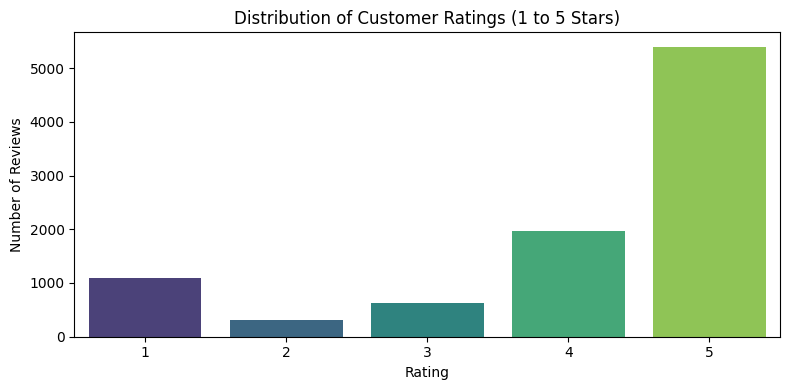


Top Products by Review Count:


,count
product_title,
BoAt Rockerz 235v2 with ASAP charging Version 5.0 Bluetooth Headset,1921
realme Buds Wireless Bluetooth Headset,980
OnePlus Bullets Wireless Z Bluetooth Headset,980
realme Buds 2 Wired Headset,977
BoAt BassHeads 100 Wired Headset,969


In [3]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="rating", palette="viridis")
plt.title("Distribution of Customer Ratings (1 to 5 Stars)")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

print("\nTop Products by Review Count:")
display(df["product_title"].value_counts().head(5))

##4. Load Pretrained BERT Sentiment and ABSA Models

In [4]:
DEVICE = 0 if torch.cuda.is_available() else -1

SENTIMENT_MODEL = "textattack/bert-base-uncased-SST-2"
ABSA_MODEL = "yangheng/deberta-v3-base-absa-v1.1"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    tokenizer=SENTIMENT_MODEL,
    device=DEVICE
)

absa_pipeline = pipeline(
    "text-classification",
    model=ABSA_MODEL,
    tokenizer=ABSA_MODEL,
    device=DEVICE
)

print("BERT Sentiment and ABSA Models Loaded Successfully!")
print("Execution Device:", "GPU" if DEVICE == 0 else "CPU")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


BERT Sentiment and ABSA Models Loaded Successfully!
Execution Device: CPU


##5. Single Review Sentiment Analysis Engine

In [5]:
def analyze_single_review(review_text):
    result = sentiment_pipeline(review_text[:512])[0]
    return {
        "label": result["label"],
        "confidence": round(result["score"] * 100, 2)
    }

sample_review = df["review"].iloc[0]
analysis = analyze_single_review(sample_review)

print("Review Snippet:", sample_review[:150], "...")
print("Overall Sentiment:", analysis["label"])
print("Confidence:", f"{analysis['confidence']}%")

Review Snippet: 1-more flexible2-bass is very high3-sound clarity is good 4-battery back up to 6 to 8 hour's 5-main thing is fastest charging system is available in t ...
Overall Sentiment: LABEL_1
Confidence: 78.13%


##6. spaCy Aspect Extraction Engine for Electronics

In [6]:
def extract_aspect_candidates(text):
    doc = nlp(text)
    aspects = []
    seen = set()
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"] and len(token.text) > 2:
            key = token.text.lower()
            if key not in seen:
                aspects.append(token.text.lower())
                seen.add(key)
    return aspects

sample_aspects = extract_aspect_candidates(sample_review)
print("Extracted Aspects from Sample Review:", sample_aspects)

Extracted Aspects from Sample Review: ['flexible2', 'bass', 'clarity', 'battery', 'hour', 'thing', 'system', 'charge', 'hours', 'look', 'gaming', 'product', 'music', 'headphones', 'pric']


##7. Automatic ABSA Pipeline for Flipkart Reviews

In [7]:
def run_absa(review_text, custom_aspects=None):
    if custom_aspects is None:
        custom_aspects = extract_aspect_candidates(review_text)

    results = []
    for aspect in custom_aspects:
        pred = absa_pipeline(review_text[:512], text_pair=aspect)[0]
        results.append({
            "Aspect": aspect,
            "Sentiment": pred["label"],
            "Confidence %": round(pred["score"] * 100, 2)
        })
    return pd.DataFrame(results)

absa_df = run_absa(sample_review)
display(absa_df)

,Aspect,Sentiment,Confidence %
0,flexible2,Positive,98.60
1,bass,Positive,99.43
2,clarity,Positive,98.91
3,battery,Positive,93.21
4,hour,Positive,92.83
5,thing,Positive,93.22
6,system,Positive,94.42
7,charge,Positive,88.07
8,hours,Positive,91.22
9,look,Positive,99.12


##8. Batch Review Processing and Product Aspect Dashboard

In [8]:
target_product = df["product_title"].value_counts().index[0]
product_reviews = df[df["product_title"] == target_product].head(20)

target_aspects = ["sound", "bass", "battery", "price", "charging", "quality"]

all_absa_records = []

for idx, row in product_reviews.iterrows():
    text = str(row["review"])
    for aspect in target_aspects:
        if aspect in text.lower():
            pred = absa_pipeline(text[:512], text_pair=aspect)[0]
            all_absa_records.append({
                "product": target_product,
                "aspect": aspect,
                "sentiment": pred["label"],
                "confidence": pred["score"]
            })

batch_absa_df = pd.DataFrame(all_absa_records)
display(batch_absa_df.head(10))

,product,aspect,sentiment,confidence
0,BoAt Rockerz 235v2 with ASAP charging Version ...,sound,Positive,0.991247
1,BoAt Rockerz 235v2 with ASAP charging Version ...,bass,Positive,0.994317
2,BoAt Rockerz 235v2 with ASAP charging Version ...,battery,Positive,0.932072
3,BoAt Rockerz 235v2 with ASAP charging Version ...,charging,Positive,0.956402
4,BoAt Rockerz 235v2 with ASAP charging Version ...,sound,Positive,0.998049
5,BoAt Rockerz 235v2 with ASAP charging Version ...,price,Positive,0.989057
6,BoAt Rockerz 235v2 with ASAP charging Version ...,sound,Positive,0.997499
7,BoAt Rockerz 235v2 with ASAP charging Version ...,bass,Positive,0.998235
8,BoAt Rockerz 235v2 with ASAP charging Version ...,battery,Positive,0.960754
9,BoAt Rockerz 235v2 with ASAP charging Version ...,sound,Positive,0.990522


##9. Product Aspect Sentiment Visual Dashboard

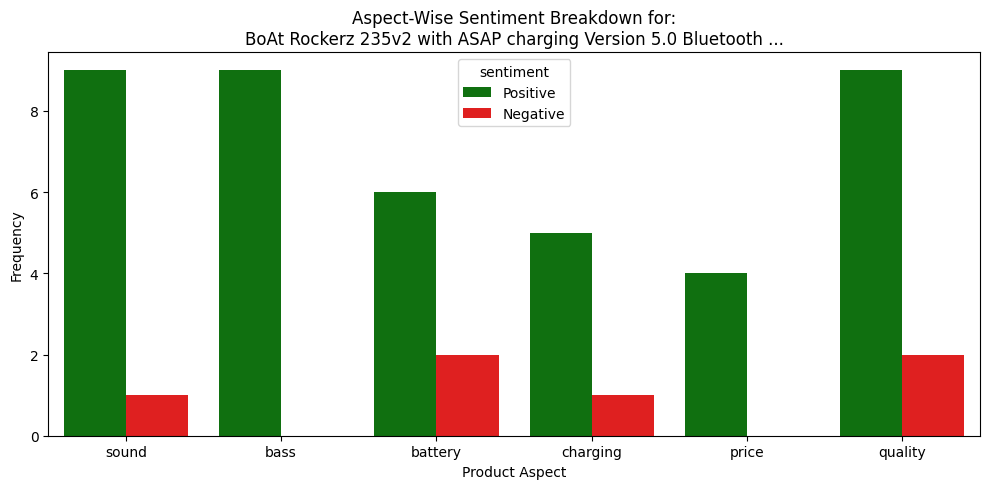

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=batch_absa_df,
    x="aspect",
    hue="sentiment",
    palette={"Positive": "green", "Negative": "red", "Neutral": "gray"}
)
plt.title(f"Aspect-Wise Sentiment Breakdown for:\n{target_product[:60]}...")
plt.xlabel("Product Aspect")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##10. Interactive Flipkart Review Analyzer

In [10]:
user_review = input("Enter a Flipkart product review: ")
user_aspects_input = input("Enter key aspects to evaluate (separated by commas): ")

user_aspects = [a.strip().lower() for a in user_aspects_input.split(",") if a.strip()]

if not user_aspects:
    user_aspects = extract_aspect_candidates(user_review)

print("\n--- OVERALL BERT SENTIMENT ---")
overall_res = analyze_single_review(user_review)
print(f"Overall Label : {overall_res['label']}")
print(f"Confidence    : {overall_res['confidence']}%\n")

print("--- ASPECT-BASED SENTIMENT ANALYSIS ---")
interactive_results = run_absa(user_review, custom_aspects=user_aspects)
display(interactive_results)

Enter a Flipkart product review: The sound quality is crisp and the bass is deep, but the bluetooth connectivity disconnects often and the build quality feels cheap.
Enter key aspects to evaluate (separated by commas): sound, bass, bluetooth, build quality

--- OVERALL BERT SENTIMENT ---
Overall Label : LABEL_0
Confidence    : 98.57%

--- ASPECT-BASED SENTIMENT ANALYSIS ---


,Aspect,Sentiment,Confidence %
0,sound,Positive,99.43
1,bass,Positive,99.40
2,bluetooth,Negative,99.65
3,build quality,Negative,99.40
